##  Section 1 – Imports & Setup
Load all required libraries for both classification and regression tasks, and configure plotting style and random seed.

In [3]:
# ── IMPORTS & SETUP ─────────────────────────────────────────────────────────
# Loads libraries for: file handling (os, glob), data manipulation (pandas,
# numpy), plotting (matplotlib, seaborn), classification AND regression models
# (scikit-learn), and all evaluation metrics for both task types
# glob is used to load multiple CSV files from the spotify_yearly folder
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded')

Libraries loaded


##  Section 2 – Load & Combine Dataset
Set the working directory, load all 8 yearly CSV files, and combine them into one DataFrame.

The Spotify Yearly Track Metadata dataset spans releases from 2014 to 2026 and contains track-level metadata including title, artist, duration, release date, and a query category label. Unlike audio-feature datasets, this dataset required feature engineering to extract predictive signals. Two machine learning tasks were performed: a five-class classification task predicting which query category (love, night, remix, rock, sad) a track belongs to, and a regression task predicting track duration in minutes.

In [4]:
# ── SET WORKING DIRECTORY ───────────────────────────────────────────────────
# Change Python's current folder to your ML_Project directory
# os.listdir() confirms the spotify_yearly subfolder is visible
# Set working directory — update to your ML_Project folder
os.chdir(r'C:\Users\Julia\Desktop\data\CSCI 164-Final Project')
print(os.getcwd())
print(os.listdir('.'))

C:\Users\Julia\Desktop\CSCI 164-Final Project
['.ipynb_checkpoints', 'CSCI164MLproject.pptx - Google Slides.pdf', 'heart.csv', 'heart_disease.ipynb', 'Housing.csv', 'housing_prices.ipynb', 'spotify_yearly', 'spotify_yearly.ipynb']


In [5]:
# ── LOAD & COMBINE ALL YEARLY CSV FILES ─────────────────────────────────────
# glob finds all .csv files inside the spotify_yearly subfolder
# Each file covers a different year range (2014-2020, 2021, 2022, etc.)
# Column names are lowercased for consistency across files
# pd.concat() stacks all 8 DataFrames into one combined dataset
# Expected result: ~14,000 rows x 7 columns before cleaning
# Load and combine all yearly CSV files from the extracted folder
# Place all CSVs in a subfolder called 'spotify_yearly' inside ML_Project
dfs = []
for f in sorted(glob.glob('spotify_yearly/*.csv')):
    df = pd.read_csv(f)
    df.columns = [c.lower() for c in df.columns]  # normalize column casing
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
print(f'Combined shape (before cleaning): {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Combined shape (before cleaning): 12,412 rows x 7 columns


,track_id,track_name,duration_min,artists,release_date,year,query
0,6dBUzqjtbnIa1TwYbyw5CM,Lovers Rock,3.57,TV Girl,6/5/2014,2014,love
1,5J4ZkQpzMUFojo1CtAZYpn,Love Me Harder,3.94,"Ariana Grande, The Weeknd",8/22/2014,2014,love
2,2e3Ea0o24lReQFR4FA7yXH,Love Yourz,3.52,J. Cole,12/9/2014,2014,love
3,6nGeLlakfzlBcFdZXteDq7,Love Story,5.27,Indila,1/1/2014,2014,love
4,5BJSZocnCeSNeYMj3iVqM7,Love Runs Out,3.74,OneRepublic,1/1/2014,2014,love


##  Section 3 – Exploratory Data Analysis (EDA)
Inspect the combined dataset structure, statistics, missing values, and category distributions.

Why This Dataset?

•	Temporal coverage: Spanning 2014–2026, it captures changes in track metadata patterns across over a decade of music releases.

•	Dual task capability: The query label enables classification while the numeric duration column supports regression, allowing both task types to be demonstrated in a single dataset.

•	Feature engineering challenge: With no pre-built audio features, the dataset requires engineering new predictors, making it a stronger test of the full ML pipeline


In [6]:
# ── DATA TYPES & STRUCTURE ──────────────────────────────────────────────────
# df.info() shows: column names, data types, and non-null counts
# Key columns: track_id (str), track_name (str), duration_min (float),
#              artists (str), release_date (str), year (int), query (str)
# Note: this dataset has NO audio features — only metadata
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12412 entries, 0 to 12411
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   track_id      12412 non-null  str    
 1   track_name    12412 non-null  str    
 2   duration_min  12412 non-null  float64
 3   artists       12412 non-null  str    
 4   release_date  12412 non-null  str    
 5   year          12412 non-null  int64  
 6   query         12412 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 678.9 KB


In [7]:
# ── SUMMARY STATISTICS ──────────────────────────────────────────────────────
# df.describe() shows statistics for numeric columns only
# Key things to check: duration_min range (outliers?), year range (2014-2026)
df.describe()

,duration_min,year
count,12412.000000,12412.000000
mean,3.411255,2022.538753
std,2.443428,2.959539
min,0.520000,2014.000000
25%,2.660000,2021.000000
50%,3.260000,2023.000000
75%,3.870000,2025.000000
max,180.470000,2026.000000


In [8]:
# ── MISSING VALUE CHECK ─────────────────────────────────────────────────────
# Count nulls per column across the combined dataset
# Any nulls in track_id, query, or duration_min will be dropped in preprocessing
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
track_id        0
track_name      0
duration_min    0
artists         0
release_date    0
year            0
query           0
dtype: int64


In [9]:
# ── TARGET VARIABLE & YEAR DISTRIBUTION ────────────────────────────────────
# query: the classification target — 5 categories (love, night, remix, rock, sad)
# Each category reflects the Spotify search term used to collect those tracks
# year: shows how many tracks exist per year — useful context for modeling
print('Unique query categories:')
print(df['query'].value_counts())
print()
print('Year range:')
print(df['year'].value_counts().sort_index())

Unique query categories:
query
sad      2552
remix    2514
rock     2497
night    2434
love     2415
Name: count, dtype: int64

Year range:
year
2014     299
2015     296
2016     303
2017     275
2018     207
2019     205
2020     116
2021    1792
2022    1796
2023    1788
2024    1772
2025    1773
2026    1790
Name: count, dtype: int64


##  Section 4 – Visualizations
Plot track counts, duration distributions, and yearly duration trends.

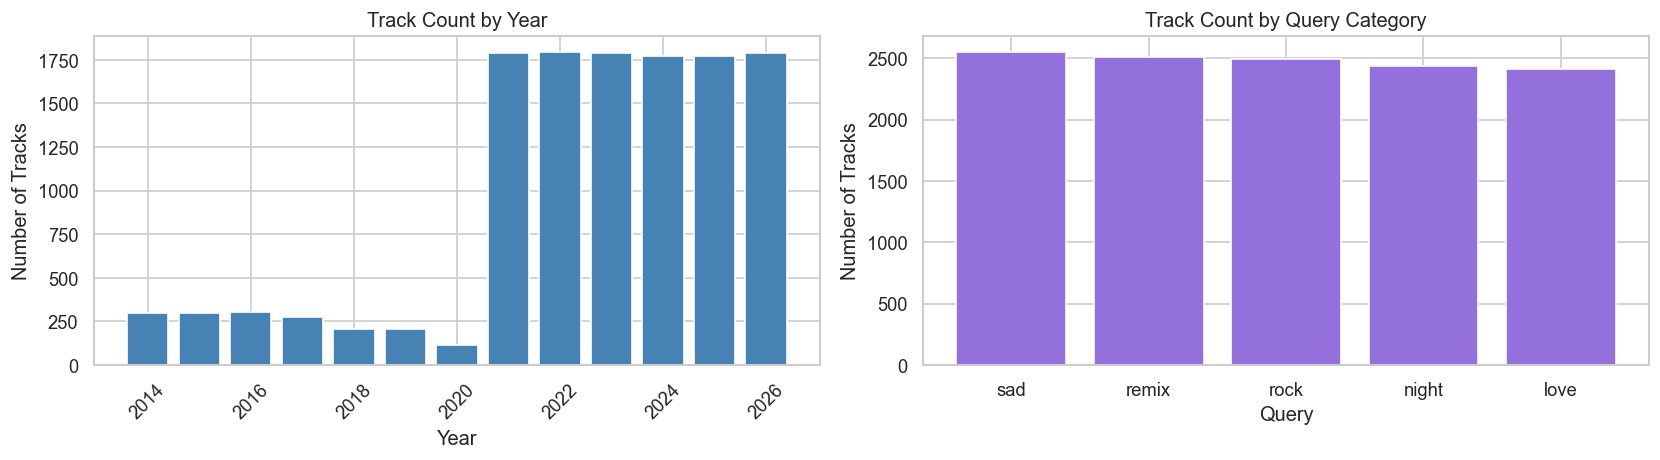

In [10]:
# ── TRACK COUNT BY YEAR & QUERY CATEGORY ────────────────────────────────────
# Left: bar chart of how many tracks exist per release year
# Right: bar chart of how many tracks belong to each query category
# Balanced query counts = no class imbalance correction needed for classification
# Track count per year
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

year_counts = df.dropna(subset=['year'])['year'].value_counts().sort_index()
axes[0].bar(year_counts.index.astype(int), year_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Track Count by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Tracks')
axes[0].tick_params(axis='x', rotation=45)

query_counts = df['query'].value_counts()
axes[1].bar(query_counts.index, query_counts.values, color='mediumpurple', edgecolor='white')
axes[1].set_title('Track Count by Query Category')
axes[1].set_xlabel('Query')
axes[1].set_ylabel('Number of Tracks')

plt.tight_layout()
plt.show()

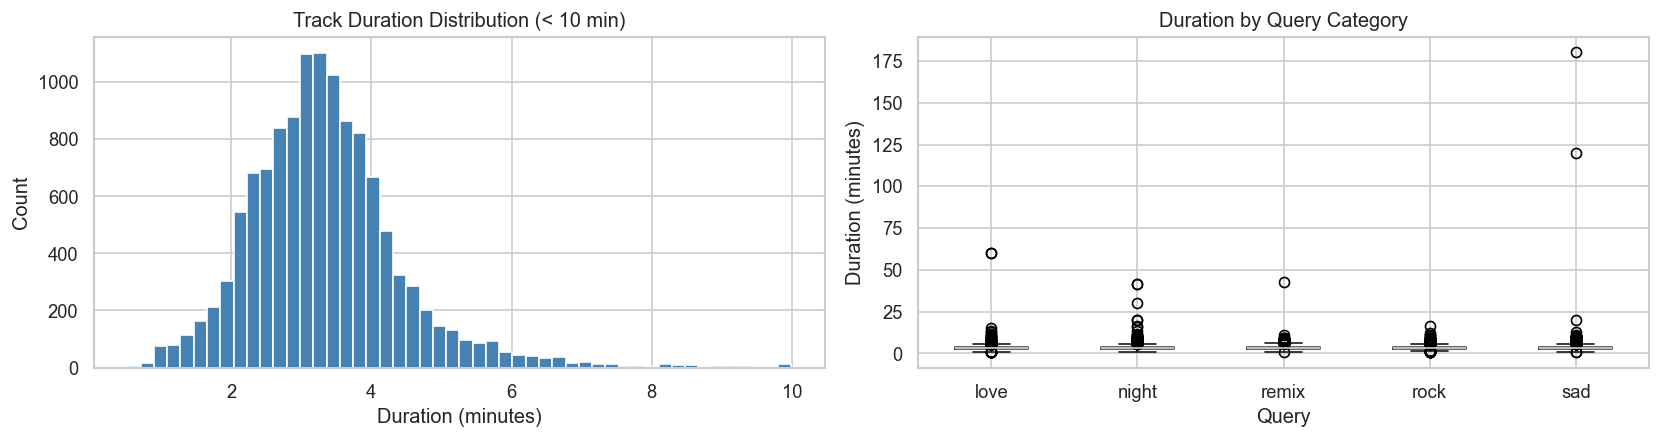

In [11]:
# ── DURATION DISTRIBUTION & BOXPLOT BY QUERY ────────────────────────────────
# Left: histogram of duration (filtered to <10 min to remove podcast outliers)
# Right: boxplot of duration split by query category
# Shows whether different query types tend to have different song lengths
# Duration distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clean_dur = df[df['duration_min'] < 10]['duration_min']
axes[0].hist(clean_dur, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Track Duration Distribution (< 10 min)')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')

df.dropna(subset=['duration_min','query']).boxplot(
    column='duration_min', by='query', ax=axes[1])
axes[1].set_title('Duration by Query Category')
axes[1].set_xlabel('Query')
axes[1].set_ylabel('Duration (minutes)')
plt.suptitle('')

plt.tight_layout()
plt.show()

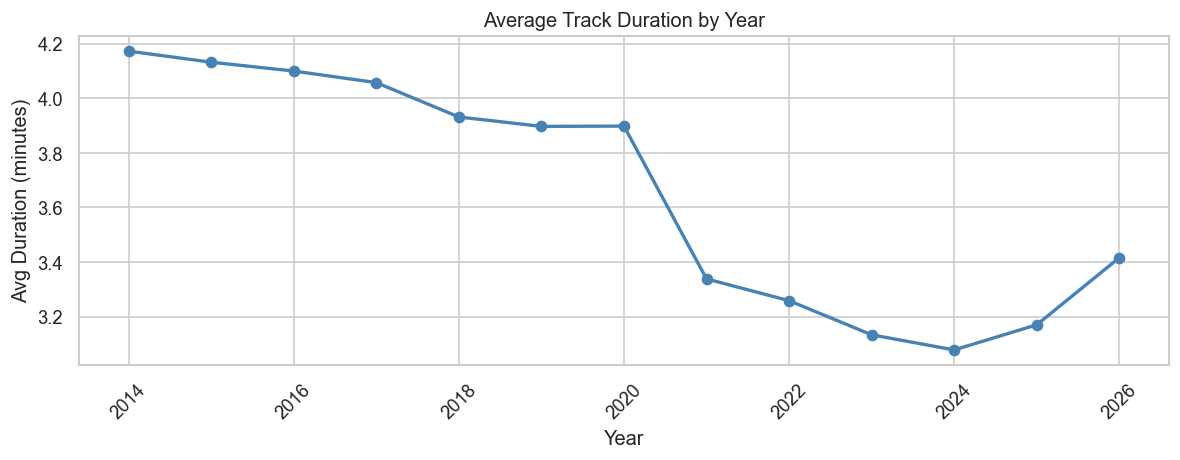

In [12]:
# ── AVERAGE TRACK DURATION BY YEAR ──────────────────────────────────────────
# Line chart showing how average song length has changed from 2014 to 2026
# Useful context: songs have generally gotten shorter in the streaming era
# This temporal signal is captured by the year feature in our models
# Average duration per year
avg_dur = df[df['duration_min'] < 10].groupby('year')['duration_min'].mean()

plt.figure(figsize=(10, 4))
plt.plot(avg_dur.index.astype(int), avg_dur.values, marker='o', color='steelblue', linewidth=2)
plt.title('Average Track Duration by Year')
plt.xlabel('Year')
plt.ylabel('Avg Duration (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Section 5 – Preprocessing & Feature Engineering
Clean the data, remove outliers, and engineer new features from the raw metadata.

In [13]:
# ── PREPROCESSING: CLEAN & FILTER ───────────────────────────────────────────
# Step 1: Drop rows missing track_id, track_name, year, duration_min, or query
# Step 2: Remove duplicate track_ids to prevent data leakage
# Step 3: Remove duration outliers > 15 min (likely podcasts or mislogged)
# Result: ~12,400 clean rows ready for feature engineering
# Drop rows missing key columns
df_clean = df.dropna(subset=['track_id', 'track_name', 'year', 'duration_min', 'query']).copy()
df_clean.drop_duplicates(subset='track_id', inplace=True)

# Remove outlier durations (> 15 min — likely podcasts or mislogged)
df_clean = df_clean[df_clean['duration_min'] < 15].copy()

print(f'Clean shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')

Clean shape: 12,397 rows x 7 columns


In [14]:
# ── FEATURE ENGINEERING ─────────────────────────────────────────────────────
# Since this dataset has NO audio features, we create new predictors from metadata:
#   release_month: month the track was released (1-12) — seasonal patterns
#   release_day:   day of month released (1-31)
#   num_artists:   number of collaborating artists (split on comma)
#   track_name_len: word count of the track title (proxy for title complexity)
# query column is label-encoded: love=0, night=1, remix=2, rock=3, sad=4
# Feature engineering from release_date
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean['release_month'] = df_clean['release_date'].dt.month.fillna(0).astype(int)
df_clean['release_day']   = df_clean['release_date'].dt.day.fillna(0).astype(int)

# Feature: number of artists on a track
df_clean['num_artists'] = df_clean['artists'].fillna('').apply(
    lambda x: len(x.split(',')))

# Feature: track name length (word count)
df_clean['track_name_len'] = df_clean['track_name'].fillna('').apply(
    lambda x: len(x.split()))

# Encode query (target for classification)
le_query = LabelEncoder()
df_clean['query_encoded'] = le_query.fit_transform(df_clean['query'])
print('Query class mapping:', dict(zip(le_query.classes_, le_query.transform(le_query.classes_))))

df_clean[['year','duration_min','release_month','release_day',
          'num_artists','track_name_len','query','query_encoded']].head()

Query class mapping: {'love': np.int64(0), 'night': np.int64(1), 'remix': np.int64(2), 'rock': np.int64(3), 'sad': np.int64(4)}


,year,duration_min,release_month,release_day,num_artists,track_name_len,query,query_encoded
0,2014,3.57,6,5,1,2,love,0
1,2014,3.94,8,22,2,3,love,0
2,2014,3.52,12,9,1,2,love,0
3,2014,5.27,1,1,1,2,love,0
4,2014,3.74,1,1,1,3,love,0


In [15]:
# ── DEFINE FEATURES, TASKS, SPLITS & SCALING ───────────────────────────────
# SHARED FEATURES: year, duration_min, release_month, release_day,
#                  num_artists, track_name_len
# TASK A — CLASSIFICATION: predict query category (5 classes)
#   Target: query_encoded (0-4), stratified 80/20 split
#   Scaling: StandardScaler applied for LR and k-NN
# TASK B — REGRESSION: predict duration_min (continuous)
#   Features: year, release_month, release_day, num_artists, track_name_len
#   (duration_min excluded from regression features since it IS the target)
#   Scaling: StandardScaler applied for Linear Regression
# Define shared features
FEATURES = ['year', 'duration_min', 'release_month', 'release_day',
            'num_artists', 'track_name_len']

X = df_clean[FEATURES]

# ── TASK A: Classification — predict query category ────────────────────────
y_class = df_clean['query_encoded']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.20, random_state=RANDOM_STATE, stratify=y_class)

scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc  = scaler_c.transform(X_test_c)

# ── TASK B: Regression — predict duration_min ──────────────────────────────
FEATURES_REG = ['year', 'release_month', 'release_day', 'num_artists', 'track_name_len']
X_reg = df_clean[FEATURES_REG]
y_reg = df_clean['duration_min']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE)

scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print(f'Classification — Train: {X_train_c.shape[0]:,} | Test: {X_test_c.shape[0]:,}')
print(f'Regression     — Train: {X_train_r.shape[0]:,} | Test: {X_test_r.shape[0]:,}')

Classification — Train: 9,917 | Test: 2,480
Regression     — Train: 9,917 | Test: 2,480


##  Section 6 – Baseline Model Development
Define evaluation helpers and train baseline classifiers and regressors.

In [16]:
# ── EVALUATION HELPER FUNCTIONS ─────────────────────────────────────────────
# evaluate_classifier(): fits a classifier, prints accuracy, weighted F1,
#   5-fold CV scores, and a full classification report per query category
# evaluate_regressor(): fits a regressor, prints MAE, MSE, RMSE, R2,
#   and 5-fold CV R2 scores
# Both functions return a results dictionary for later comparison tables
# ── Classification evaluation helper ──────────────────────────────────────────
def evaluate_classifier(model, X_tr, X_te, y_tr, y_te, name, cv=5):
    model.fit(X_tr, y_tr)
    y_pred    = model.predict(X_te)
    acc       = accuracy_score(y_te, y_pred)
    f1        = f1_score(y_te, y_pred, average='weighted')
    cv_scores = cross_val_score(
        model, X_tr, y_tr,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='accuracy')
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Test Accuracy : {acc:.4f}')
    print(f'  Weighted F1   : {f1:.4f}')
    print(f'  CV Accuracy   : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=le_query.classes_))
    return {'model': model, 'name': name, 'y_pred': y_pred,
            'acc': acc, 'f1': f1,
            'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}


# ── Regression evaluation helper ───────────────────────────────────────────────
def evaluate_regressor(model, X_tr, X_te, y_tr, y_te, name, cv=5):
    model.fit(X_tr, y_tr)
    y_pred    = model.predict(X_te)
    mae       = mean_absolute_error(y_te, y_pred)
    mse       = mean_squared_error(y_te, y_pred)
    rmse      = np.sqrt(mse)
    r2        = r2_score(y_te, y_pred)
    cv_scores = cross_val_score(
        model, X_tr, y_tr,
        cv=KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='r2')
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  MAE  : {mae:.4f}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R2   : {r2:.4f}')
    print(f'  CV R2: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    return {'model': model, 'name': name, 'y_pred': y_pred,
            'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2,
            'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}

In [17]:
# ── CLASSIFICATION BASELINE 1: LOGISTIC REGRESSION ─────────────────────────
# Linear probabilistic classifier for 5-class query prediction
# Uses scaled features (X_train_c_sc / X_test_c_sc)
# max_iter=1000 ensures convergence on this multi-class problem
# Classification Model 1 — Logistic Regression
res_lr = evaluate_classifier(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train_c_sc, X_test_c_sc, y_train_c, y_test_c,
    'Logistic Regression'
)


  Logistic Regression
  Test Accuracy : 0.3520
  Weighted F1   : 0.3160
  CV Accuracy   : 0.3593 +/- 0.0138

              precision    recall  f1-score   support

        love       0.25      0.18      0.21       482
       night       0.21      0.05      0.08       486
       remix       0.54      0.72      0.62       503
        rock       0.32      0.53      0.40       499
         sad       0.26      0.27      0.26       510

    accuracy                           0.35      2480
   macro avg       0.32      0.35      0.31      2480
weighted avg       0.32      0.35      0.32      2480



In [18]:
# ── CLASSIFICATION BASELINE 2: DECISION TREE ────────────────────────────────
# Non-linear classifier using feature threshold splits
# Uses UNSCALED features — tree-based models do not need scaling
# Untuned (no depth limit) — likely to overfit on metadata-only features
# Classification Model 2 — Decision Tree
res_dt = evaluate_classifier(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    X_train_c, X_test_c, y_train_c, y_test_c,
    'Decision Tree (untuned)'
)


  Decision Tree (untuned)
  Test Accuracy : 0.3323
  Weighted F1   : 0.3328
  CV Accuracy   : 0.3122 +/- 0.0127

              precision    recall  f1-score   support

        love       0.27      0.31      0.29       482
       night       0.25      0.27      0.26       486
       remix       0.53      0.52      0.53       503
        rock       0.33      0.30      0.32       499
         sad       0.29      0.25      0.27       510

    accuracy                           0.33      2480
   macro avg       0.33      0.33      0.33      2480
weighted avg       0.33      0.33      0.33      2480



In [19]:
# ── CLASSIFICATION BASELINE 3: K-NEAREST NEIGHBORS (k=11) ─────────────────
# Classifies each track by majority vote of its 11 nearest neighbors
# Uses scaled features — distance-based models require scaling
# k=11 is a reasonable starting default for a 5-class problem
# Classification Model 3 — k-NN
res_knn = evaluate_classifier(
    KNeighborsClassifier(n_neighbors=11),
    X_train_c_sc, X_test_c_sc, y_train_c, y_test_c,
    'k-Nearest Neighbors (k=11)'
)


  k-Nearest Neighbors (k=11)
  Test Accuracy : 0.3605
  Weighted F1   : 0.3523
  CV Accuracy   : 0.3596 +/- 0.0110

              precision    recall  f1-score   support

        love       0.26      0.30      0.28       482
       night       0.27      0.23      0.25       486
       remix       0.56      0.69      0.62       503
        rock       0.36      0.35      0.35       499
         sad       0.29      0.23      0.26       510

    accuracy                           0.36      2480
   macro avg       0.35      0.36      0.35      2480
weighted avg       0.35      0.36      0.35      2480



In [20]:
# ── REGRESSION BASELINE 1: LINEAR REGRESSION ────────────────────────────────
# Fits a linear relationship between metadata features and track duration
# Uses scaled features for Linear Regression
# Serves as the interpretable baseline for the regression task
# Regression Model 1 — Linear Regression
res_linreg = evaluate_regressor(
    LinearRegression(),
    X_train_r_sc, X_test_r_sc, y_train_r, y_test_r,
    'Linear Regression'
)


  Linear Regression
  MAE  : 0.7758
  MSE  : 1.2367
  RMSE : 1.1121
  R2   : 0.0632
  CV R2: 0.0712 +/- 0.0097


In [21]:
# ── REGRESSION BASELINE 2: DECISION TREE REGRESSOR ─────────────────────────
# Predicts duration using threshold-based splits on metadata features
# Uses UNSCALED features
# Untuned tree will likely overfit — CV R2 expected to be low/negative
# Regression Model 2 — Decision Tree Regressor
res_dtr = evaluate_regressor(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    X_train_r, X_test_r, y_train_r, y_test_r,
    'Decision Tree Regressor (untuned)'
)


  Decision Tree Regressor (untuned)
  MAE  : 0.8019
  MSE  : 1.3374
  RMSE : 1.1564
  R2   : -0.0130
  CV R2: -0.0704 +/- 0.0630


##  Section 7 – Hyperparameter Tuning
Use GridSearchCV with 5-fold cross-validation to optimize each model.

Key findings from tuning: for classifiers, a shallow max_depth of 5 consistently outperformed deeper trees, indicating that deeper trees overfit given the limited feature set. For k-NN, Manhattan distance with distance-weighted voting and a large neighborhood (k=31) performed best, suggesting that local density patterns are diffuse and require many neighbors to be stable. For the regressor, pruning significantly improved generalization versus the untuned tree

In [22]:
# ── GRIDSEARCHCV: LOGISTIC REGRESSION (CLASSIFIER) ─────────────────────────
# Tests combinations of:
#   C: regularization strength (lower = more regularization)
#   solver: lbfgs (default) vs saga (better for large datasets)
# Scored by accuracy — 5-fold stratified CV to preserve class proportions
# GridSearchCV — Logistic Regression
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    {'C': [0.01, 0.1, 1.0, 10.0], 'solver': ['lbfgs', 'saga']},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1, verbose=1
)
gs_lr.fit(X_train_c_sc, y_train_c)
print('Best params:', gs_lr.best_params_)
print(f'Best CV accuracy: {gs_lr.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 0.1, 'solver': 'saga'}
Best CV accuracy: 0.3594


In [23]:
# ── GRIDSEARCHCV: DECISION TREE CLASSIFIER ──────────────────────────────────
# Tests combinations of:
#   max_depth: limits tree growth to prevent overfitting
#   min_samples_split: min rows to allow a split at a node
#   criterion: gini impurity vs information entropy for split quality
# 30 total combinations, 5-fold CV = 150 fits
# GridSearchCV — Decision Tree Classifier
gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {'max_depth': [5, 10, 15, 20, None],
     'min_samples_split': [2, 10, 20],
     'criterion': ['gini', 'entropy']},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1, verbose=1
)
gs_dt.fit(X_train_c, y_train_c)
print('Best params:', gs_dt.best_params_)
print(f'Best CV accuracy: {gs_dt.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best CV accuracy: 0.3665


In [24]:
# ── GRIDSEARCHCV: K-NEAREST NEIGHBORS (CLASSIFIER) ─────────────────────────
# Tests combinations of:
#   n_neighbors: k=5 to k=31 (larger k = smoother, less noise-sensitive)
#   weights: uniform (equal vote) vs distance (closer neighbors weighted more)
#   metric: euclidean vs manhattan distance between feature vectors
# 16 combinations x 5-fold CV = 80 fits
# GridSearchCV — k-NN
gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [5, 11, 21, 31],
     'weights': ['uniform', 'distance'],
     'metric': ['euclidean', 'manhattan']},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy', n_jobs=-1, verbose=1
)
gs_knn.fit(X_train_c_sc, y_train_c)
print('Best params:', gs_knn.best_params_)
print(f'Best CV accuracy: {gs_knn.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 31, 'weights': 'distance'}
Best CV accuracy: 0.3663


In [25]:
# ── GRIDSEARCHCV: DECISION TREE REGRESSOR ───────────────────────────────────
# Tests combinations of:
#   max_depth: prunes the tree to reduce overfitting on small training data
#   min_samples_split: controls minimum node size before splitting
#   criterion: squared_error (penalizes large errors) vs
#              absolute_error (more robust to outlier durations)
# Scored by R2 — KFold (not stratified) since this is a regression task
# GridSearchCV — Decision Tree Regressor
gs_dtr = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    {'max_depth': [3, 5, 10, 15, None],
     'min_samples_split': [2, 10, 20],
     'criterion': ['squared_error', 'absolute_error']},
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='r2', n_jobs=-1, verbose=1
)
gs_dtr.fit(X_train_r, y_train_r)
print('Best params:', gs_dtr.best_params_)
print(f'Best CV R2: {gs_dtr.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 20}
Best CV R2: 0.0821


##  Section 8 – Evaluate Tuned Models
Test the best configurations from GridSearchCV on the held-out test sets.

In [26]:
# ── EVALUATE TUNED CLASSIFIERS ON TEST SET ──────────────────────────────────
# best_estimator_ = the classifier config with highest CV accuracy
# Each tuned model is now tested on the 20% classification test set
# it has never seen during training or cross-validation
# Evaluate all tuned classifiers
res_lr_tuned  = evaluate_classifier(gs_lr.best_estimator_,  X_train_c_sc, X_test_c_sc, y_train_c, y_test_c, 'Logistic Regression (tuned)')
res_dt_tuned  = evaluate_classifier(gs_dt.best_estimator_,  X_train_c,    X_test_c,    y_train_c, y_test_c, 'Decision Tree (tuned)')
res_knn_tuned = evaluate_classifier(gs_knn.best_estimator_, X_train_c_sc, X_test_c_sc, y_train_c, y_test_c, 'k-NN (tuned)')


  Logistic Regression (tuned)
  Test Accuracy : 0.3524
  Weighted F1   : 0.3164
  CV Accuracy   : 0.3594 +/- 0.0138

              precision    recall  f1-score   support

        love       0.25      0.18      0.21       482
       night       0.21      0.05      0.08       486
       remix       0.54      0.72      0.62       503
        rock       0.32      0.53      0.40       499
         sad       0.26      0.27      0.27       510

    accuracy                           0.35      2480
   macro avg       0.32      0.35      0.31      2480
weighted avg       0.32      0.35      0.32      2480


  Decision Tree (tuned)
  Test Accuracy : 0.3694
  Weighted F1   : 0.3522
  CV Accuracy   : 0.3665 +/- 0.0107

              precision    recall  f1-score   support

        love       0.29      0.16      0.21       482
       night       0.26      0.20      0.23       486
       remix       0.57      0.76      0.65       503
        rock       0.37      0.38      0.37       499
         s

In [27]:
# ── EVALUATE TUNED REGRESSOR ON TEST SET ────────────────────────────────────
# best_estimator_ = Decision Tree Regressor config with highest CV R2
# Evaluated on the 20% regression test set
# Linear Regression has no hyperparameters — its baseline result is final
# Evaluate tuned regressor
res_dtr_tuned = evaluate_regressor(gs_dtr.best_estimator_, X_train_r, X_test_r, y_train_r, y_test_r, 'Decision Tree Regressor (tuned)')


  Decision Tree Regressor (tuned)
  MAE  : 0.7676
  MSE  : 1.2179
  RMSE : 1.1036
  R2   : 0.0774
  CV R2: 0.0821 +/- 0.0159


##  Section 9 – Results, Evaluation & Visualizations
Compare all models and generate all evaluation plots for both tasks.

In [28]:
# ── CLASSIFICATION SUMMARY TABLE ────────────────────────────────────────────
# Collects Test Accuracy, Weighted F1, CV Mean, and CV Std
# for all 6 classification models (3 baseline + 3 tuned)
# Sorted by Test Accuracy (highest first)
# Classification summary table
clf_results = [res_lr, res_dt, res_knn, res_lr_tuned, res_dt_tuned, res_knn_tuned]
clf_summary = pd.DataFrame([{
    'Model'      : r['name'],
    'Test Acc'   : round(r['acc'], 4),
    'Weighted F1': round(r['f1'], 4),
    'CV Mean'    : round(r['cv_mean'], 4),
    'CV Std'     : round(r['cv_std'], 4)
} for r in clf_results])
clf_summary.sort_values('Test Acc', ascending=False, inplace=True)
clf_summary.reset_index(drop=True, inplace=True)
print('=== CLASSIFICATION RESULTS ===')
clf_summary

=== CLASSIFICATION RESULTS ===


,Model,Test Acc,Weighted F1,CV Mean,CV Std
0,k-NN (tuned),0.3726,0.3652,0.3663,0.0048
1,Decision Tree (tuned),0.3694,0.3522,0.3665,0.0107
2,k-Nearest Neighbors (k=11),0.3605,0.3523,0.3596,0.0110
3,Logistic Regression (tuned),0.3524,0.3164,0.3594,0.0138
4,Logistic Regression,0.3520,0.3160,0.3593,0.0138
5,Decision Tree (untuned),0.3323,0.3328,0.3122,0.0127


In [29]:
# ── REGRESSION SUMMARY TABLE ────────────────────────────────────────────────
# Collects MAE, RMSE, R2, and CV R2 for all 3 regression models
# (Linear Regression baseline, DT untuned, DT tuned)
# Sorted by R2 (highest first) — primary regression metric
# Regression summary table
reg_results = [res_linreg, res_dtr, res_dtr_tuned]
reg_summary = pd.DataFrame([{
    'Model': r['name'],
    'MAE'  : round(r['mae'], 4),
    'RMSE' : round(r['rmse'], 4),
    'R2'   : round(r['r2'], 4),
    'CV R2': round(r['cv_mean'], 4)
} for r in reg_results])
reg_summary.sort_values('R2', ascending=False, inplace=True)
reg_summary.reset_index(drop=True, inplace=True)
print('=== REGRESSION RESULTS ===')
reg_summary

=== REGRESSION RESULTS ===


,Model,MAE,RMSE,R2,CV R2
0,Decision Tree Regressor (tuned),0.7676,1.1036,0.0774,0.0821
1,Linear Regression,0.7758,1.1121,0.0632,0.0712
2,Decision Tree Regressor (untuned),0.8019,1.1564,-0.0130,-0.0704


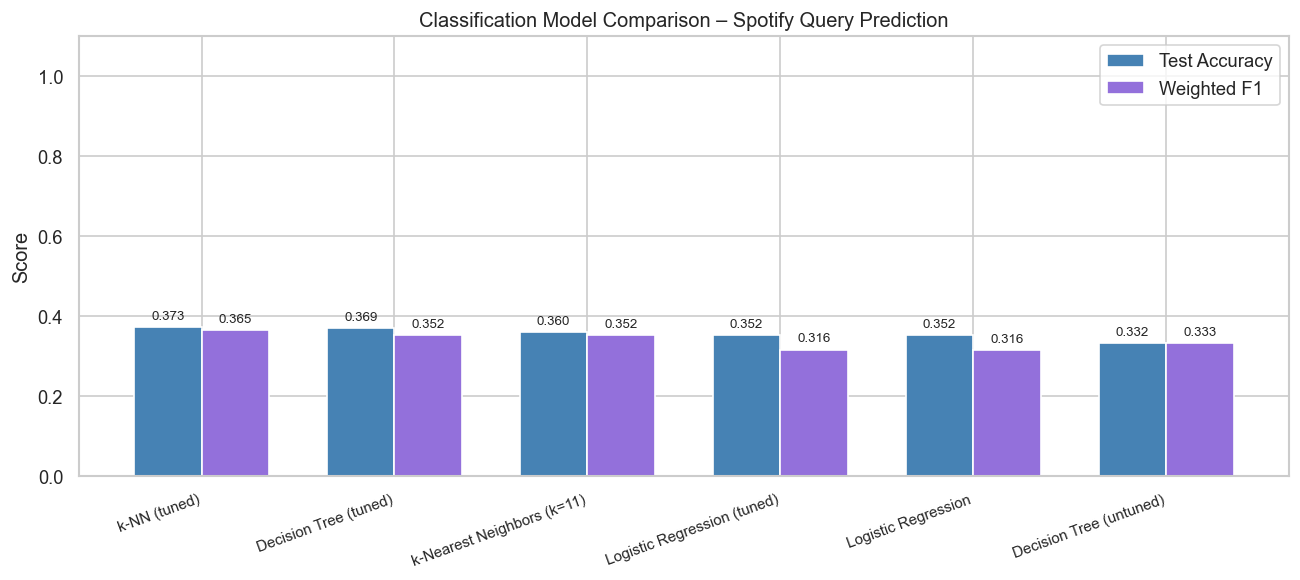

In [30]:
# ── CLASSIFICATION MODEL COMPARISON BAR CHART ───────────────────────────────
# Side-by-side bars: Test Accuracy vs Weighted F1 for all 6 classifiers
# The 5-class random baseline is 20% — all models should exceed this
# Low overall accuracy is expected since query labels come from search terms,
# not intrinsic audio properties that metadata can capture
# Classification model comparison bar chart
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(clf_summary))
w = 0.35
b1 = ax.bar(x - w/2, clf_summary['Test Acc'],    w, label='Test Accuracy', color='steelblue')
b2 = ax.bar(x + w/2, clf_summary['Weighted F1'], w, label='Weighted F1',   color='mediumpurple')
ax.bar_label(b1, fmt='{:.3f}', padding=3, fontsize=8)
ax.bar_label(b2, fmt='{:.3f}', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(clf_summary['Model'], rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison – Spotify Query Prediction')
ax.legend()
plt.tight_layout()
plt.show()

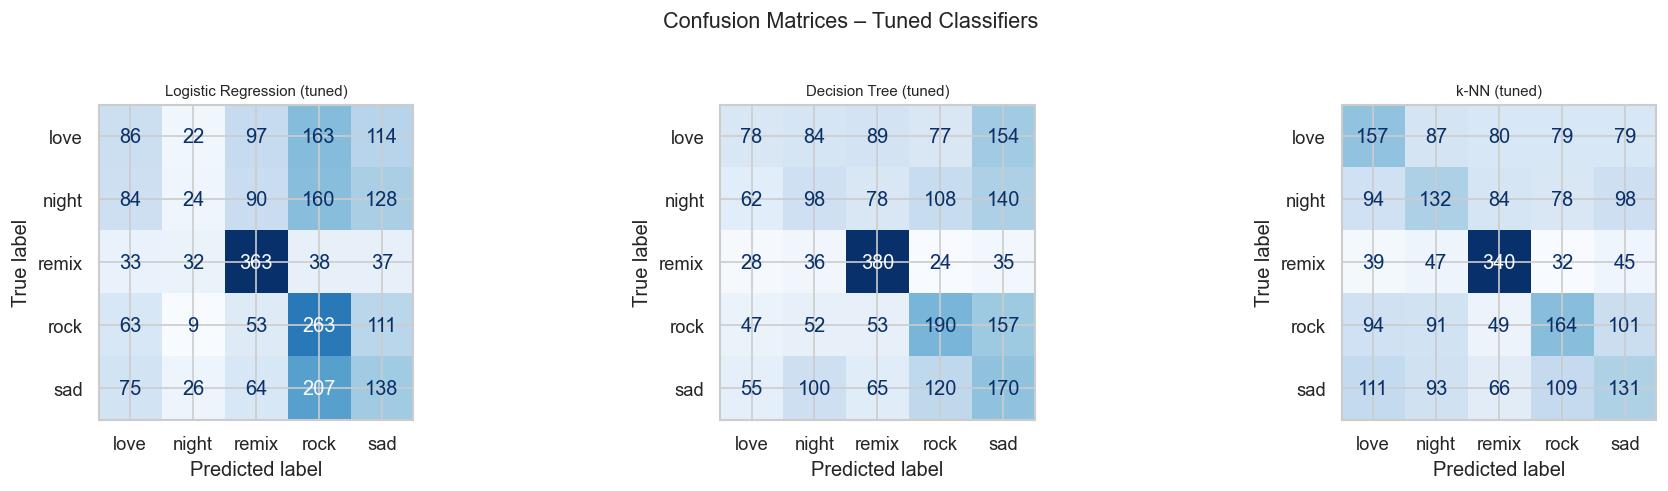

In [31]:
# ── CONFUSION MATRICES (TUNED CLASSIFIERS) ──────────────────────────────────
# 5x5 grid for each model showing predicted vs actual query categories
# Diagonal cells = correct predictions
# Off-diagonal cells = misclassifications
# Expect remix to be predicted most accurately (it has distinct patterns)
# Confusion matrices — tuned classifiers
tuned_clf = [res_lr_tuned, res_dt_tuned, res_knn_tuned]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, res in zip(axes, tuned_clf):
    cm = confusion_matrix(y_test_c, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=le_query.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['name'], fontsize=9)
plt.suptitle('Confusion Matrices – Tuned Classifiers', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

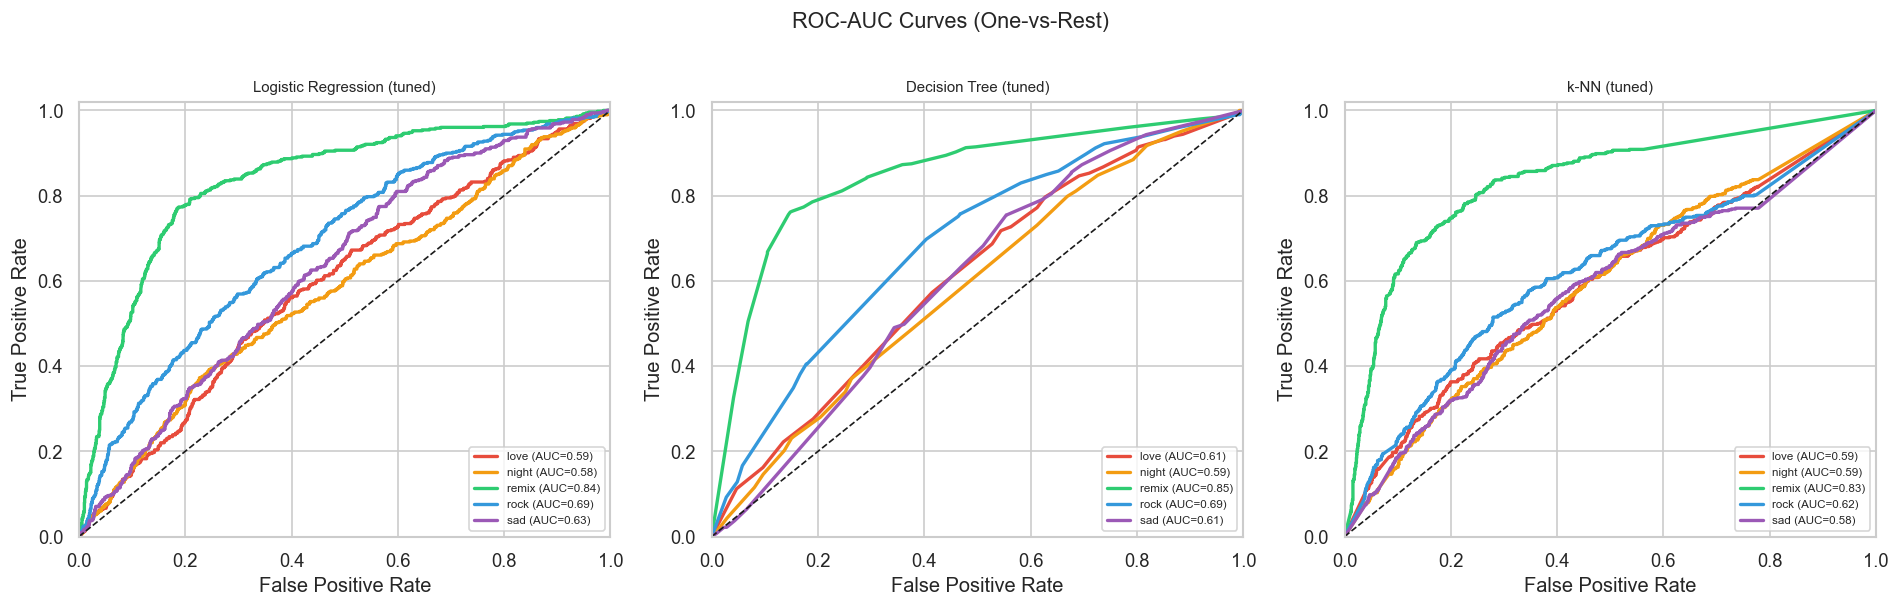

In [32]:
# ── ROC-AUC CURVES (ONE-VS-REST, 5 CLASSES) ────────────────────────────────
# One ROC curve per query category per model (one-vs-rest strategy)
# AUC = area under the curve — closer to 1.0 = better discrimination
# Diagonal dashed line = random classifier (AUC = 0.5)
# label_binarize() converts 5-class labels into 5 binary columns for plotting
# ROC-AUC curves (One-vs-Rest)
y_test_bin = label_binarize(y_test_c, classes=list(range(len(le_query.classes_))))
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']

roc_models = [
    (gs_lr.best_estimator_,  X_test_c_sc, 'Logistic Regression (tuned)'),
    (gs_dt.best_estimator_,  X_test_c,    'Decision Tree (tuned)'),
    (gs_knn.best_estimator_, X_test_c_sc, 'k-NN (tuned)'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (model, X_te, name) in zip(axes, roc_models):
    y_score = model.predict_proba(X_te)
    for i, (cls, color) in enumerate(zip(le_query.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC={auc:.2f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name, fontsize=9)
    ax.legend(loc='lower right', fontsize=7)
plt.suptitle('ROC-AUC Curves (One-vs-Rest)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

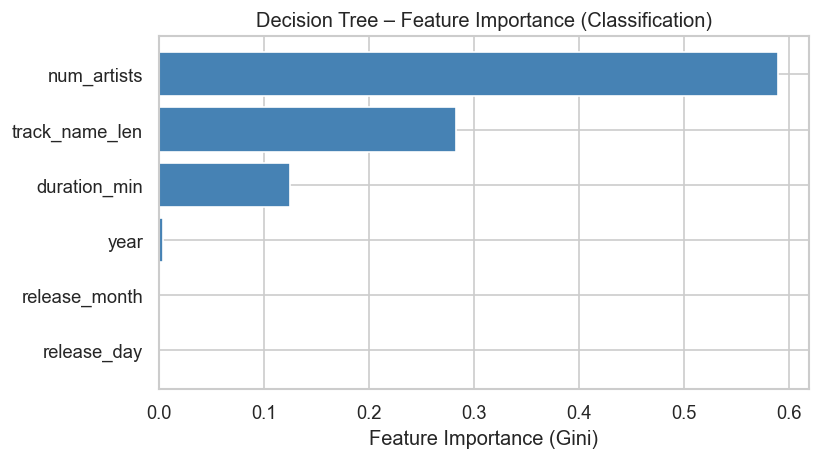

In [33]:
# ── FEATURE IMPORTANCE: DECISION TREE CLASSIFIER ───────────────────────────
# Gini importance: how much each feature reduces class impurity across splits
# Higher bar = more important for predicting query category
# With only metadata features, year and duration_min are expected to rank highest
# Feature importance — tuned Decision Tree Classifier
importances = gs_dt.best_estimator_.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df.sort_values('Importance', ascending=True, inplace=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree – Feature Importance (Classification)')
plt.tight_layout()
plt.show()

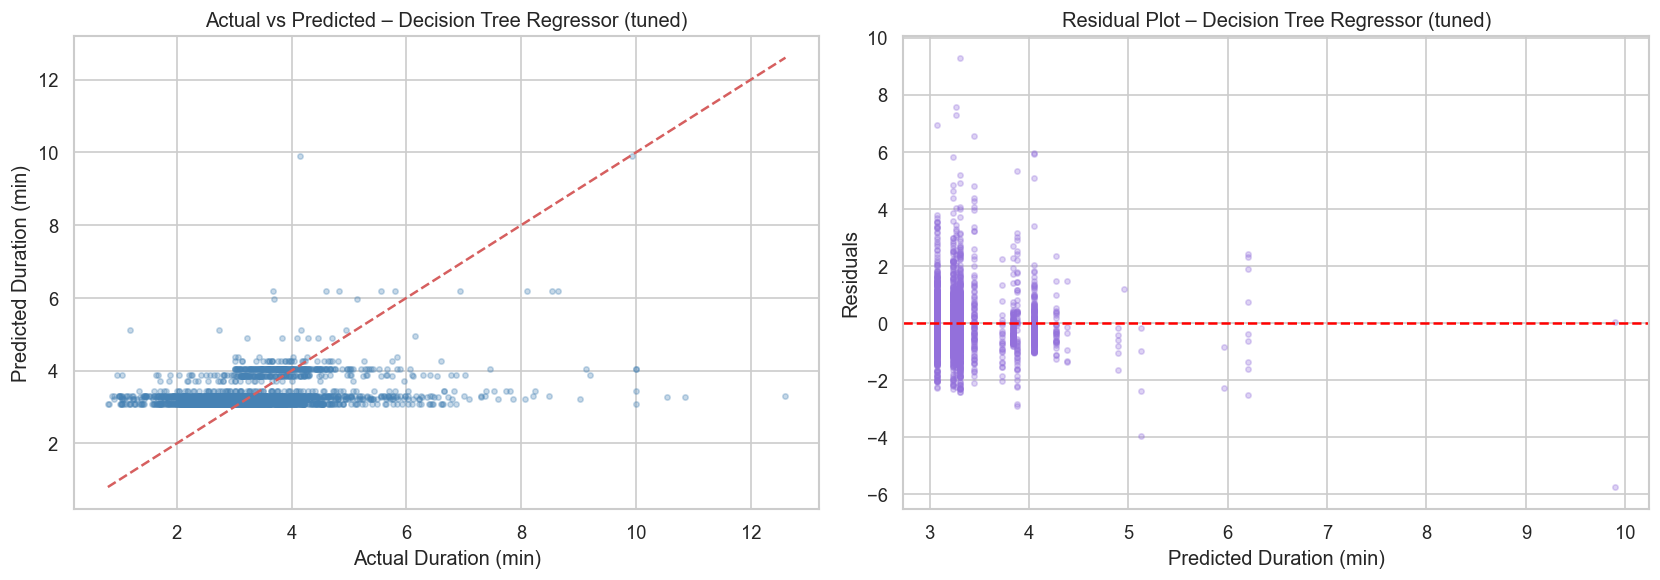

In [34]:
# ── REGRESSION EVALUATION PLOTS ─────────────────────────────────────────────
# Left — Actual vs Predicted (tuned Decision Tree Regressor):
#   Each dot = one track; red dashed line = perfect predictions
#   Spread around the line = prediction error (RMSE)
# Right — Residual Plot:
#   Residual = actual duration minus predicted duration
#   Random scatter around 0 = good model; patterns = systematic errors
#   Low R2 expected since metadata explains little of duration variance
# Regression plots — Actual vs Predicted + Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Best regressor predictions
best_reg_pred = res_dtr_tuned['y_pred']
residuals     = y_test_r.values - best_reg_pred

axes[0].scatter(y_test_r, best_reg_pred, alpha=0.3, color='steelblue', s=10)
lims = [min(y_test_r.min(), best_reg_pred.min()),
        max(y_test_r.max(), best_reg_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual Duration (min)')
axes[0].set_ylabel('Predicted Duration (min)')
axes[0].set_title('Actual vs Predicted – Decision Tree Regressor (tuned)')

axes[1].scatter(best_reg_pred, residuals, alpha=0.3, color='mediumpurple', s=10)
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Duration (min)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot – Decision Tree Regressor (tuned)')

plt.tight_layout()
plt.show()

##  Section 10 – Final Summary
Print the complete ranked results for both classification and regression tasks.

In [35]:

# ── FINAL RESULTS PRINTOUT ───────────────────────────────────────────────────
# Prints two ranked summary tables:
#   1. Classification: query category prediction (5-class, ~37% best accuracy)
#   2. Regression: track duration prediction (R2 ~0.08 best)
# Low scores are expected — this dataset has no audio features,
# so metadata alone provides limited predictive power for both tasks
# Final summary printout
print('=' * 60)
print('  CLASSIFICATION RESULTS – QUERY CATEGORY PREDICTION')
print('=' * 60)
print(clf_summary.to_string(index=False))
print()
print('=' * 60)
print('  REGRESSION RESULTS – TRACK DURATION PREDICTION')
print('=' * 60)
print(reg_summary.to_string(index=False))
print('=' * 60)

  CLASSIFICATION RESULTS – QUERY CATEGORY PREDICTION
                      Model  Test Acc  Weighted F1  CV Mean  CV Std
               k-NN (tuned)    0.3726       0.3652   0.3663  0.0048
      Decision Tree (tuned)    0.3694       0.3522   0.3665  0.0107
 k-Nearest Neighbors (k=11)    0.3605       0.3523   0.3596  0.0110
Logistic Regression (tuned)    0.3524       0.3164   0.3594  0.0138
        Logistic Regression    0.3520       0.3160   0.3593  0.0138
    Decision Tree (untuned)    0.3323       0.3328   0.3122  0.0127

  REGRESSION RESULTS – TRACK DURATION PREDICTION
                            Model    MAE   RMSE      R2   CV R2
  Decision Tree Regressor (tuned) 0.7676 1.1036  0.0774  0.0821
                Linear Regression 0.7758 1.1121  0.0632  0.0712
Decision Tree Regressor (untuned) 0.8019 1.1564 -0.0130 -0.0704


This analysis demonstrates that a metadata-only Spotify dataset provides limited but meaningful predictive power for both classification and regression tasks. The tuned k-NN classifier achieved the highest test accuracy of 37.26% on a 5-class query prediction problem, outperforming the Logistic Regression baseline and the untuned Decision Tree. The tuned Decision Tree Regressor achieved the best regression performance with R2 = 0.077 and MAE = 0.768 minutes for track duration prediction.

All results fall below the prior work benchmark of 47.27%, which is expected given the absence of audio features in this dataset. The primary lesson drawn is that audio features are essential for meaningful Spotify track modeling; metadata alone is insufficient for high-accuracy predictions. Future improvements could include integrating Spotify API audio features, applying text embeddings to artist names and track titles, or using temporal trend features to capture era-specific music patterns.
